## Problem Statement:
 Implement content-based filtering using a neural network to build a recommender system for movies.

In [19]:
import numpy as np
import numpy.ma as ma
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
import tabulate
from collections import defaultdict
import csv
import pickle
from tensorflow.keras.layers import Lambda
pd.set_option("display.precision", 1)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

%matplotlib inline

Mounted at /content/drive


In [3]:
top10_df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/content_top10_df.csv")
bygenre_df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/content_bygenre_df.csv")
top10_df

,movie id,num ratings,ave rating,title,genres
0,4993,198,4.1,"Lord of the Rings: The Fellowship of the Ring,...",Adventure|Fantasy
1,5952,188,4.0,"Lord of the Rings: The Two Towers, The",Adventure|Fantasy
2,7153,185,4.1,"Lord of the Rings: The Return of the King, The",Action|Adventure|Drama|Fantasy
3,4306,170,3.9,Shrek,Adventure|Animation|Children|Comedy|Fantasy|Ro...
4,58559,149,4.2,"Dark Knight, The",Action|Crime|Drama
5,6539,149,3.8,Pirates of the Caribbean: The Curse of the Bla...,Action|Adventure|Comedy|Fantasy
6,79132,143,4.1,Inception,Action|Crime|Drama|Mystery|Sci-Fi|Thriller
7,6377,141,4.0,Finding Nemo,Adventure|Animation|Children|Comedy
8,4886,132,3.9,"Monsters, Inc.",Adventure|Animation|Children|Comedy|Fantasy
9,7361,131,4.2,Eternal Sunshine of the Spotless Mind,Drama|Romance|Sci-Fi


In [4]:
bygenre_df

,genre,num movies,ave rating/genre,ratings per genre
0,Action,321,3.4,10377
1,Adventure,234,3.4,8785
2,Animation,76,3.6,2588
3,Children,69,3.4,2472
4,Comedy,326,3.4,8911
5,Crime,139,3.5,4671
6,Documentary,13,3.8,280
7,Drama,342,3.6,10201
8,Fantasy,124,3.4,4468
9,Horror,56,3.2,1345


## Content-based filtering with a neural network:
Content-based filtering generates a user and movie feature vector but recognizes there may be other information available about the user and/or movie that may improve the prediction. The additional information is provided to a neural network which then generates the user and movie vector as shown below:
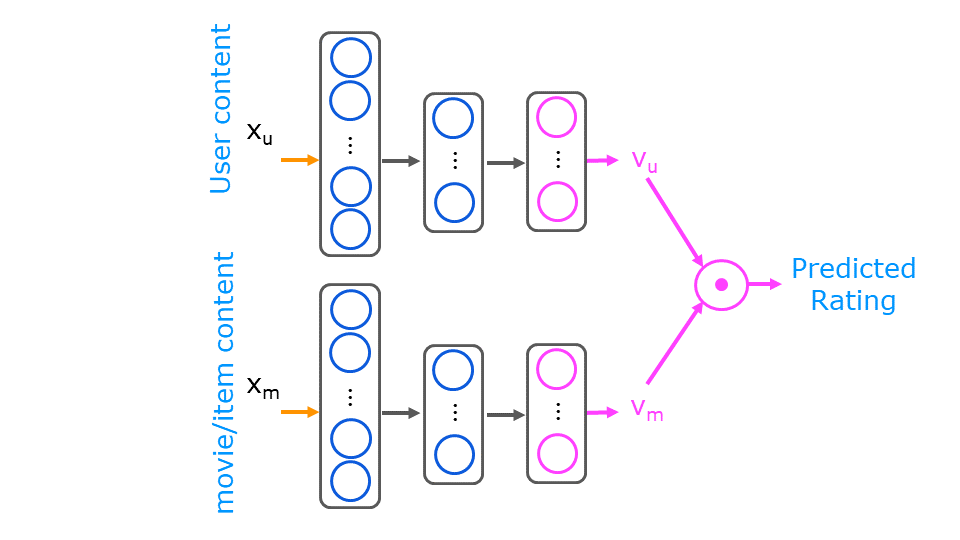

In [10]:
item_train = np.genfromtxt('/content/drive/MyDrive/Colab Notebooks/content_item_train.csv', delimiter=',')
user_train = np.genfromtxt('/content/drive/MyDrive/Colab Notebooks/content_user_train.csv', delimiter=',')
y_train    = np.genfromtxt('/content/drive/MyDrive/Colab Notebooks/content_y_train.csv', delimiter=',')
with open('/content/drive/MyDrive/Colab Notebooks/content_item_train_header.txt', newline='') as f:    #csv reader handles quoted strings better
    item_features = list(csv.reader(f))[0]
with open('/content/drive/MyDrive/Colab Notebooks/content_user_train_header.txt', newline='') as f:
    user_features = list(csv.reader(f))[0]
item_vecs = np.genfromtxt('/content/drive/MyDrive/Colab Notebooks/content_item_vecs.csv', delimiter=',')

movie_dict = defaultdict(dict)
count = 0
#    with open('./data/movies.csv', newline='') as csvfile:
with open('/content/drive/MyDrive/Colab Notebooks/content_movie_list.csv', newline='') as csvfile:
    reader = csv.reader(csvfile, delimiter=',', quotechar='"')
    for line in reader:
        if count == 0:
            count += 1  #skip header
            #print(line) print
        else:
            count += 1
            movie_id = int(line[0])
            movie_dict[movie_id]["title"] = line[1]
            movie_dict[movie_id]["genres"] = line[2]

with open('/content/drive/MyDrive/Colab Notebooks/content_user_to_genre.pickle', 'rb') as f:
    user_to_genre = pickle.load(f)

<ipython-input-10-69b68108c93b>:26: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  user_to_genre = pickle.load(f)


In [11]:
num_user_features = user_train.shape[1] - 3  # remove userid, rating count and ave rating during training
num_item_features = item_train.shape[1] - 1  # remove movie id at train time
uvs = 3  # user genre vector start
ivs = 3  # item genre vector start
u_s = 3  # start of columns to use in training, user
i_s = 1  # start of columns to use in training, items
print(f"Number of training vectors: {len(item_train)}")

Number of training vectors: 50884


In [14]:
print(f"y_train[:5]: {y_train[:5]}")

y_train[:5]: [4.  3.5 4.  4.  4.5]


Preparing the training data:

In [15]:
# scale training data
item_train_unscaled = item_train
user_train_unscaled = user_train
y_train_unscaled    = y_train

scalerItem = StandardScaler()
scalerItem.fit(item_train)
item_train = scalerItem.transform(item_train)

scalerUser = StandardScaler()
scalerUser.fit(user_train)
user_train = scalerUser.transform(user_train)

scalerTarget = MinMaxScaler((-1, 1))
scalerTarget.fit(y_train.reshape(-1, 1))
y_train = scalerTarget.transform(y_train.reshape(-1, 1))
#ynorm_test = scalerTarget.transform(y_test.reshape(-1, 1))

print(np.allclose(item_train_unscaled, scalerItem.inverse_transform(item_train)))
print(np.allclose(user_train_unscaled, scalerUser.inverse_transform(user_train)))

True
True


In [16]:
item_train, item_test = train_test_split(item_train, train_size=0.80, shuffle=True, random_state=1)
user_train, user_test = train_test_split(user_train, train_size=0.80, shuffle=True, random_state=1)
y_train, y_test       = train_test_split(y_train,    train_size=0.80, shuffle=True, random_state=1)
print(f"movie/item training data shape: {item_train.shape}")
print(f"movie/item test data shape: {item_test.shape}")

movie/item training data shape: (40707, 17)
movie/item test data shape: (10177, 17)


## Neural Network for content-based filtering:

In [20]:
num_outputs = 32
tf.random.set_seed(1)
user_NN = tf.keras.models.Sequential([
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(num_outputs)
])

item_NN = tf.keras.models.Sequential([
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(num_outputs)
])

# create the user input and point to the base network
input_user = tf.keras.layers.Input(shape=(num_user_features,))
vu = user_NN(input_user)
# vu = tf.linalg.l2_normalize(vu, axis=1)
vu = Lambda(lambda x: tf.linalg.l2_normalize(x, axis=1))(vu)

# create the item input and point to the base network
input_item = tf.keras.layers.Input(shape=(num_item_features,))
vm = item_NN(input_item)
# vm = tf.linalg.l2_normalize(vm, axis=1)
vm = Lambda(lambda x: tf.linalg.l2_normalize(x, axis=1))(vm)

# compute the dot product of the two vectors vu and vm
output = tf.keras.layers.Dot(axes=1)([vu, vm])

# specify the inputs and output of the model
model = tf.keras.Model([input_user, input_item], output)

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 14)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_5       │ (None, 16)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_4        │ (None, 32)        │     40,864 │ input_layer_3[0]… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_5        │ (None, 32)        │     41,376 │ input_layer_5[0]… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 32)        │          0 │ sequential_4[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 32)        │          0 │ sequential_5[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dot (Dot)           │ (None, 1)         │          0 │ lambda[0][0],     │
│                     │                   │            │ lambda_1[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 82,240 (321.25 KB)

 Trainable params: 82,240 (321.25 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
tf.random.set_seed(1)
cost_fn = tf.keras.losses.MeanSquaredError()
opt = keras.optimizers.Adam(learning_rate=0.01)
model.compile(optimizer=opt,
              loss=cost_fn)

In [22]:
tf.random.set_seed(1)
model.fit([user_train[:, u_s:], item_train[:, i_s:]], y_train, epochs=30)

Epoch 1/30
1273/1273 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 0.1313
Epoch 2/30
1273/1273 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 0.1150
Epoch 3/30
1273/1273 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.1103
Epoch 4/30
1273/1273 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.1061
Epoch 5/30
1273/1273 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.1032
Epoch 6/30
1273/1273 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.1005
Epoch 7/30
1273/1273 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.0977
Epoch 8/30
1273/1273 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.0952
Epoch 9/30
1273/1273 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0931
Epoch 10/30
1273/1273 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0914
Epoch 11/30
1273/1273 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.0898
Epoch 12/30
1273/1273 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0882
Epoch 13/30
1273/1273 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0867
Epoch 14/30
1273/1273 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0852
Epoch 15/30
1273/1273 ━━━━━━━

In [23]:
model.evaluate([user_test[:, u_s:], item_test[:, i_s:]], y_test)

319/319 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0871


0.08348719030618668

## Predictions:

### a) Predictions for a new user:
  Create a new user and have the model suggest movies for that user.

In [24]:
new_user_id = 5000
new_rating_ave = 0.0
new_action = 0.0
new_adventure = 5.0
new_animation = 0.0
new_childrens = 0.0
new_comedy = 0.0
new_crime = 0.0
new_documentary = 0.0
new_drama = 0.0
new_fantasy = 5.0
new_horror = 0.0
new_mystery = 0.0
new_romance = 0.0
new_scifi = 0.0
new_thriller = 0.0
new_rating_count = 3

user_vec = np.array([[new_user_id, new_rating_count, new_rating_ave,
                      new_action, new_adventure, new_animation, new_childrens,
                      new_comedy, new_crime, new_documentary,
                      new_drama, new_fantasy, new_horror, new_mystery,
                      new_romance, new_scifi, new_thriller]])

The new user enjoys movies from the adventure, fantasy genres.

In [25]:
# generate and replicate the user vector to match the number movies in the data set.
user_vecs = np.tile(user_vec, (len(item_vecs), 1))

# scale our user and item vectors
suser_vecs = scalerUser.transform(user_vecs)
sitem_vecs = scalerItem.transform(item_vecs)

# make a prediction
y_p = model.predict([suser_vecs[:, u_s:], sitem_vecs[:, i_s:]])

# unscale y prediction
y_pu = scalerTarget.inverse_transform(y_p)

# sort the results, highest prediction first
sorted_index = np.argsort(-y_pu,axis=0).reshape(-1).tolist()  #negate to get largest rating first
sorted_ypu   = y_pu[sorted_index]
sorted_items = item_vecs[sorted_index]  #using unscaled vectors for display

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


In [27]:
import tabulate

def print_pred_movies(y_p, item, movie_dict, maxcount=10, title_width=50, genre_width=30):
    """ Pretty print prediction results for a new user using tabulate in HTML format. """
    count = 0
    disp = [["Pred", "Movie ID", "Avg Rating", "Title", "Genres"]]

    for i in range(min(maxcount, y_p.shape[0])):
        movie_id = int(item[i, 0])
        pred_rating = round(y_p[i, 0], 1)
        avg_rating = round(float(item[i, 2]), 1)
        title = movie_dict[movie_id]['title'][:title_width] + "..." if len(movie_dict[movie_id]['title']) > title_width else movie_dict[movie_id]['title']
        genres = movie_dict[movie_id]['genres'][:genre_width] + "..." if len(movie_dict[movie_id]['genres']) > genre_width else movie_dict[movie_id]['genres']

        disp.append([pred_rating, movie_id, avg_rating, title, genres])

    table = tabulate.tabulate(disp, tablefmt='html', headers='firstrow', colalign=("center",)*5)
    return table


In [29]:
from IPython.display import display, HTML

# Generate the HTML table string
html_table = print_pred_movies(sorted_ypu, sorted_items, movie_dict, maxcount=10)

# Display it in the notebook
display(HTML(html_table))


Pred,Movie ID,Avg Rating,Title,Genres
4.4,40815,3.8,Harry Potter and the Goblet of Fire (2005),Adventure|Fantasy|Thriller
4.4,5816,3.6,Harry Potter and the Chamber of Secrets (2002),Adventure|Fantasy
4.3,98809,3.8,"Hobbit: An Unexpected Journey, The (2012)",Adventure|Fantasy
4.3,41566,3.4,"Chronicles of Narnia: The Lion, the Witch and the ...",Adventure|Children|Fantasy
4.3,106489,3.6,"Hobbit: The Desolation of Smaug, The (2013)",Adventure|Fantasy
4.3,4896,3.8,Harry Potter and the Sorcerer's Stone (a.k.a. Harr...,Adventure|Children|Fantasy
4.2,59501,3.5,"Chronicles of Narnia: Prince Caspian, The (2008)",Adventure|Children|Fantasy
4.2,54001,3.9,Harry Potter and the Order of the Phoenix (2007),Adventure|Drama|Fantasy
4.2,137857,3.6,The Jungle Book (2016),Adventure|Drama|Fantasy
4.2,69844,3.9,Harry Potter and the Half-Blood Prince (2009),Adventure|Fantasy|Mystery|Roma...


### b) Predictions for an existing user:

In [30]:
def get_user_vecs(user_id, user_train, item_vecs, user_to_genre):
    """ given a user_id, return:
        user train/predict matrix to match the size of item_vecs
        y vector with ratings for all rated movies and 0 for others of size item_vecs """

    if not user_id in user_to_genre:
        print("error: unknown user id")
        return None
    else:
        user_vec_found = False
        for i in range(len(user_train)):
            if user_train[i, 0] == user_id:
                user_vec = user_train[i]
                user_vec_found = True
                break
        if not user_vec_found:
            print("error in get_user_vecs, did not find uid in user_train")
        num_items = len(item_vecs)
        user_vecs = np.tile(user_vec, (num_items, 1))

        y = np.zeros(num_items)
        for i in range(num_items):  # walk through movies in item_vecs and get the movies, see if user has rated them
            movie_id = item_vecs[i, 0]
            if movie_id in user_to_genre[user_id]['movies']:
                rating = user_to_genre[user_id]['movies'][movie_id]
            else:
                rating = 0
            y[i] = rating
    return(user_vecs, y)

In [32]:
uid = 2
# form a set of user vectors. This is the same vector, transformed and repeated.
user_vecs, y_vecs = get_user_vecs(uid, user_train_unscaled, item_vecs, user_to_genre)

# scale our user and item vectors
suser_vecs = scalerUser.transform(user_vecs)
sitem_vecs = scalerItem.transform(item_vecs)

# make a prediction
y_p = model.predict([suser_vecs[:, u_s:], sitem_vecs[:, i_s:]])

# unscale y prediction
y_pu = scalerTarget.inverse_transform(y_p)

# sort the results, highest prediction first
sorted_index = np.argsort(-y_pu,axis=0).reshape(-1).tolist()  #negate to get largest rating first
sorted_ypu   = y_pu[sorted_index]
sorted_items = item_vecs[sorted_index]  #using unscaled vectors for display
sorted_user  = user_vecs[sorted_index]
sorted_y     = y_vecs[sorted_index]

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


In [34]:
def print_existing_user(y_p, y, user, items, ivs, uvs, movie_dict, maxcount=10):
    """ print results of prediction for a user who was in the database.
        Inputs are expected to be in sorted order, unscaled.
    """
    count = 0
    disp = [["y_p", "y", "user", "user genre ave", "movie rating ave", "movie id", "title", "genres"]]
    count = 0
    for i in range(0, y.shape[0]):
        if y[i, 0] != 0:  # zero means not rated
            if count == maxcount:
                break
            count += 1
            movie_id = items[i, 0].astype(int)

            offsets = np.nonzero(items[i, ivs:] == 1)[0]
            genre_ratings = user[i, uvs + offsets]
            disp.append([y_p[i, 0], y[i, 0],
                         user[i, 0].astype(int),      # userid
                         np.array2string(genre_ratings,
                                         formatter={'float_kind':lambda x: "%.1f" % x},
                                         separator=',', suppress_small=True),
                         items[i, 2].astype(float),    # movie average rating
                         movie_id,
                         movie_dict[movie_id]['title'],
                         movie_dict[movie_id]['genres']])

    table = tabulate.tabulate(disp, tablefmt='html', headers="firstrow", floatfmt=[".1f", ".1f", ".0f", ".2f", ".1f"])
    return table

html_table = print_existing_user(
    sorted_ypu,
    sorted_y.reshape(-1, 1),
    sorted_user,
    sorted_items,
    ivs,
    uvs,
    movie_dict,
    maxcount=50
)

# Display the table as HTML
display(HTML(html_table))

y_p,y,user,user genre ave,movie rating ave,movie id,title,genres
4.6,4.0,2,"[4.0,4.1,3.9]",4.0,6874,Kill Bill: Vol. 1 (2003),Action|Crime|Thriller
4.5,5.0,2,[4.0],4.3,80906,Inside Job (2010),Documentary
4.3,4.5,2,"[4.0,4.1,4.0]",4.2,58559,"Dark Knight, The (2008)",Action|Crime|Drama
4.2,3.5,2,"[4.0,4.1,4.0,3.9]",3.8,8798,Collateral (2004),Action|Crime|Drama|Thriller
4.2,4.5,2,"[4.0,4.0]",4.1,68157,Inglourious Basterds (2009),Action|Drama
4.2,4.0,2,"[4.0,4.1,4.0,4.0,3.9,3.9]",4.1,79132,Inception (2010),Action|Crime|Drama|Mystery|Sci-Fi|Thriller
4.2,4.0,2,"[4.1,4.0,3.9]",4.3,48516,"Departed, The (2006)",Crime|Drama|Thriller
4.1,5.0,2,"[4.0,4.1,4.0]",3.9,106782,"Wolf of Wall Street, The (2013)",Comedy|Crime|Drama
3.9,3.5,2,"[4.0,4.0]",3.9,99114,Django Unchained (2012),Action|Drama
3.9,3.0,2,[3.9],4.0,109487,Interstellar (2014),Sci-Fi


## Finding Similar Items:
A similarity measure is the squared distance between the two vectors $ \mathbf{v_m^{(k)}}$ and $\mathbf{v_m^{(i)}}$ :
$$\left\Vert \mathbf{v_m^{(k)}} - \mathbf{v_m^{(i)}}  \right\Vert^2 = \sum_{l=1}^{n}(v_{m_l}^{(k)} - v_{m_l}^{(i)})^2\tag{1}$$

In [35]:
def sq_dist(a,b):

    d = np.sum((a - b)**2)

    return d

In [36]:
a1 = np.array([1.0, 2.0, 3.0]); b1 = np.array([1.0, 2.0, 3.0])
a2 = np.array([1.1, 2.1, 3.1]); b2 = np.array([1.0, 2.0, 3.0])
a3 = np.array([0, 1, 0]);       b3 = np.array([1, 0, 0])
print(f"squared distance between a1 and b1: {sq_dist(a1, b1):0.3f}")
print(f"squared distance between a2 and b2: {sq_dist(a2, b2):0.3f}")
print(f"squared distance between a3 and b3: {sq_dist(a3, b3):0.3f}")

squared distance between a1 and b1: 0.000
squared distance between a2 and b2: 0.030
squared distance between a3 and b3: 2.000


In [38]:
input_item_m = tf.keras.layers.Input(shape=(num_item_features,))
vm_m = item_NN(input_item_m)
vm_m = tf.keras.layers.Lambda(lambda x: tf.linalg.l2_normalize(x, axis=1))(vm_m)  # use a Lambda layer
model_m = tf.keras.Model(input_item_m, vm_m)
model_m.summary()


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_5 (Sequential)       │ (None, 32)             │        41,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_2 (Lambda)               │ (None, 32)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41,376 (161.62 KB)

 Trainable params: 41,376 (161.62 KB)

 Non-trainable params: 0 (0.00 B)

In [39]:
scaled_item_vecs = scalerItem.transform(item_vecs)
vms = model_m.predict(scaled_item_vecs[:,i_s:])
print(f"size of all predicted movie feature vectors: {vms.shape}")

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
size of all predicted movie feature vectors: (847, 32)


In [41]:
from IPython.display import display, HTML
import numpy.ma as ma
import tabulate

count = 50  # number of movies to display
dim = len(vms)
dist = np.zeros((dim, dim))

for i in range(dim):
    for j in range(dim):
        dist[i, j] = sq_dist(vms[i, :], vms[j, :])

m_dist = ma.masked_array(dist, mask=np.identity(dist.shape[0]))  # mask the diagonal

disp = [["movie1", "genres", "movie2", "genres"]]
for i in range(count):
    min_idx = np.argmin(m_dist[i])
    movie1_id = int(item_vecs[i, 0])
    movie2_id = int(item_vecs[min_idx, 0])
    disp.append([
        movie_dict[movie1_id]['title'], movie_dict[movie1_id]['genres'],
        movie_dict[movie2_id]['title'], movie_dict[movie2_id]['genres']  # fixed here
    ])

table_html = tabulate.tabulate(disp, tablefmt='html', headers="firstrow")

# Display the table nicely in notebook
display(HTML(table_html))


movie1,genres,movie2,genres
Save the Last Dance (2001),Drama|Romance,Mona Lisa Smile (2003),Drama|Romance
"Wedding Planner, The (2001)",Comedy|Romance,Mr. Deeds (2002),Comedy|Romance
Hannibal (2001),Horror|Thriller,Final Destination 2 (2003),Horror|Thriller
Saving Silverman (Evil Woman) (2001),Comedy|Romance,"Sweetest Thing, The (2002)",Comedy|Romance
Down to Earth (2001),Comedy|Fantasy|Romance,Bewitched (2005),Comedy|Fantasy|Romance
"Mexican, The (2001)",Action|Comedy,Rush Hour 2 (2001),Action|Comedy
15 Minutes (2001),Thriller,Panic Room (2002),Thriller
Enemy at the Gates (2001),Drama,Seabiscuit (2003),Drama
Heartbreakers (2001),Comedy|Crime|Romance,"10,000 BC (2008)",Adventure|Romance|Thriller
Spy Kids (2001),Action|Adventure|Children|Comedy,"Mummy Returns, The (2001)",Action|Adventure|Comedy|Thriller
